### Base de Dados para Previsão de Demanda

#### Bibliotecas

In [ ]:
import sqlite3
import pandas as pd
import random
import numpy as np
import os

from faker import Faker
from google.colab import drive
from datetime import datetime

#### Acessando o Google Drive

In [ ]:

drive.mount('/content/drive')

caminho_base = '/content/drive/MyDrive/Colab Notebooks'

nome_pasta = 'Previsao_Demanda_Avancada'

caminho_completo = os.path.join(
    caminho_base,
    nome_pasta
)

if not os.path.exists(caminho_completo):

    os.makedirs(caminho_completo)

    print(f'Pasta criada: {caminho_completo}')

else:

    print('Pasta já existe.')

os.chdir(caminho_completo)

print(f'Diretório atual: {os.getcwd()}')

#### Criando Banco e Acessando

In [ ]:

if os.path.exists('gestao_estoque.db'):

    os.remove('gestao_estoque.db')

    print('Banco antigo removido.')

conn = sqlite3.connect('gestao_estoque.db')

cursor = conn.cursor()


#### Criando Tabelas

##### Tabela de Produtos

In [ ]:
cursor.execute('''
CREATE TABLE Produtos (

    id_produto INTEGER PRIMARY KEY AUTOINCREMENT,

    nome TEXT NOT NULL,

    categoria TEXT,

    classe_abc TEXT,

    lead_time_estimado INTEGER,

    custo_unitario REAL

)
''')

##### Tabela de Movimentações

In [ ]:
cursor.execute('''
CREATE TABLE Movimentacoes (

    id_movimentacao INTEGER PRIMARY KEY AUTOINCREMENT,

    id_produto INTEGER,

    data_movimentacao DATE,

    quantidade INTEGER NOT NULL,

    tipo TEXT CHECK(tipo IN ('E', 'S')),

    valor_total REAL,

    FOREIGN KEY (id_produto)
    REFERENCES Produtos(id_produto)

)
''')

##### Tabela de Estoque

In [ ]:
cursor.execute('''
CREATE TABLE Estoque_Atual (

    id_produto INTEGER PRIMARY KEY,

    quantidade_disponivel INTEGER DEFAULT 0,

    data_ultima_atualizacao TIMESTAMP
    DEFAULT CURRENT_TIMESTAMP,

    FOREIGN KEY (id_produto)
    REFERENCES Produtos(id_produto)

)
''')

##### Trigger de Estoque

In [ ]:
cursor.execute('''
CREATE TRIGGER atualiza_estoque

AFTER INSERT ON Movimentacoes

BEGIN

    INSERT OR IGNORE INTO Estoque_Atual (

        id_produto,
        quantidade_disponivel

    )

    VALUES (

        NEW.id_produto,
        0

    );

    UPDATE Estoque_Atual

    SET quantidade_disponivel =

        quantidade_disponivel +

        CASE

            WHEN NEW.tipo = 'E'

            THEN NEW.quantidade

            ELSE -NEW.quantidade

        END,

        data_ultima_atualizacao =
        CURRENT_TIMESTAMP

    WHERE id_produto = NEW.id_produto;

END;
''')

conn.commit()

print('Tabelas criadas com sucesso.')

#### Populando as tabelas

##### Inicializando o Faker

In [ ]:
fake = Faker('pt_BR')

##### Criando Produtos

In [ ]:
classes_abc = (
    ['A'] * 10 +
    ['B'] * 20 +
    ['C'] * 20
)

random.shuffle(classes_abc)

for i in range(1, 51):

    classe = classes_abc[i - 1]

    custo = round(
        random.uniform(10, 500),
        2
    )

    lead_time = random.randint(2, 20)

    categoria = random.choice([
        'Materia-Prima',
        'Embalagem',
        'Produto Acabado'
    ])

    cursor.execute('''
    INSERT INTO Produtos (

        id_produto,
        nome,
        categoria,
        classe_abc,
        lead_time_estimado,
        custo_unitario

    )

    VALUES (?, ?, ?, ?, ?, ?)
    ''',

    (
        i,
        f'Produto {i}',
        categoria,
        classe,
        lead_time,
        custo
    ))

conn.commit()

print('Produtos inseridos.')

##### Carregando Produtos

In [ ]:
df_produtos = pd.read_sql_query(
    'SELECT * FROM Produtos',
    conn
)

ids_produtos = df_produtos[
    'id_produto'
].tolist()

##### Definindo Período Temporal

In [ ]:
data_inicio = (

    pd.Timestamp.today()

    .replace(day=1)

    - pd.DateOffset(months=24)

)

data_fim = (

    pd.Timestamp.today()

    + pd.DateOffset(months=1)

)

##### Sazonalidade

In [ ]:
sazonalidade = {

    1: 0.90,
    2: 0.95,
    3: 1.00,
    4: 1.05,
    5: 1.10,
    6: 1.15,
    7: 1.05,
    8: 1.00,
    9: 1.10,
    10: 1.20,
    11: 1.35,
    12: 1.50

}

##### Gerando Movimentações

In [ ]:

saldo = {
    id_p: random.randint(300, 800)
    for id_p in ids_produtos
}

movimentacoes = []


TOTAL_REGISTROS = 15000

WARMUP = 2000

for i in range(TOTAL_REGISTROS):

    id_prod = random.choice(ids_produtos)

    produto = df_produtos[
        df_produtos['id_produto'] == id_prod
    ].iloc[0]

    classe = produto['classe_abc']

    custo_unitario = produto['custo_unitario']

    data_aleatoria = fake.date_between_dates(

        date_start=data_inicio.date(),
        date_end=data_fim.date()

    )

    if saldo[id_prod] < 50:

        tipo = 'E'

    else:

        prob_saida = 0.70

        tipo = np.random.choice(
            ['E', 'S'],
            p=[1 - prob_saida, prob_saida]
        )

    if tipo == 'E':

        qtd = random.randint(80, 300)

    else:

        qtd = random.randint(5, 60)

    if classe == 'A':

        qtd *= 2.5

    elif classe == 'B':

        qtd *= 1.4

    else:

        qtd *= 0.7

    qtd *= sazonalidade[
        data_aleatoria.month
    ]

    meses_passados = (

        (data_aleatoria.year - data_inicio.year) * 12 +

        (data_aleatoria.month - data_inicio.month)

    )

    fator_tendencia = (
        1 + (meses_passados * 0.015)
    )

    qtd *= fator_tendencia

    if data_aleatoria.weekday() >= 5:

        qtd *= 0.65

    if (
        data_aleatoria.month == 11 and
        random.random() < 0.15
    ):

        qtd *= 2.5

    ruido = np.random.normal(

        loc=1.0,
        scale=0.12

    )

    qtd *= ruido

    qtd = max(1, int(qtd))

    if tipo == 'S':

        if saldo[id_prod] < qtd:

            continue

        saldo[id_prod] -= qtd

    else:

        saldo[id_prod] += qtd

    margem = random.uniform(1.15, 1.60)

    valor_total = round(

        custo_unitario *
        qtd *
        margem,

        2

    )

    movimentacoes.append({

        'id_produto': id_prod,

        'data_movimentacao': data_aleatoria,

        'quantidade': qtd,

        'tipo': tipo,

        'valor_total': valor_total

    })

df_movs = pd.DataFrame(movimentacoes)

print(f'Registros gerados: {len(df_movs)}')

df_movs = df_movs.iloc[WARMUP:]

print(f'Registros após warm-up: {len(df_movs)}')

df_movs['data_movimentacao'] = pd.to_datetime(
    df_movs['data_movimentacao']
)

primeiro_mes = (

    df_movs['data_movimentacao']

    .dt.to_period('M')

    .min()

)

df_movs = df_movs[

    df_movs['data_movimentacao']

    .dt.to_period('M') != primeiro_mes

]

print(f'Primeiro mês removido: {primeiro_mes}')


##### Inserindo e reconstruindo estoque

In [ ]:


df_movs.to_sql(

    'Movimentacoes',

    conn,

    if_exists='append',

    index=False

)

conn.commit()

print('Movimentações inseridas.')

cursor.execute('DELETE FROM Estoque_Atual')

cursor.execute('''
INSERT INTO Estoque_Atual (

    id_produto,
    quantidade_disponivel,
    data_ultima_atualizacao

)

SELECT

    id_produto,

    SUM(

        CASE

            WHEN tipo = 'E'

            THEN quantidade

            ELSE -quantidade

        END

    ),

    CURRENT_TIMESTAMP

FROM Movimentacoes

GROUP BY id_produto
''')

conn.commit()

print('Estoque atualizado.')

#### Consultas

In [ ]:
print('\n--- ESTOQUE ---')

df_estoque = pd.read_sql_query(

    'SELECT * FROM Estoque_Atual',
    conn

)

print(df_estoque.head())

print('\n--- MOVIMENTAÇÕES ---')

df_mov = pd.read_sql_query(

    'SELECT * FROM Movimentacoes LIMIT 5',
    conn

)

print(df_mov)

#### Exportando .CSV

In [ ]:

tabelas = [

    'Produtos',
    'Movimentacoes',
    'Estoque_Atual'

]

for tabela in tabelas:

    df_export = pd.read_sql_query(

        f'SELECT * FROM {tabela}',
        conn

    )

    nome_arquivo = f'export_{tabela.lower()}.csv'

    df_export.to_csv(

        nome_arquivo,

        index=False,

        sep=';',

        encoding='utf-8-sig'

    )

    print(f'Exportado: {nome_arquivo}')

#### Gerando gráficos

In [ ]:
import matplotlib.pyplot as plt

query = '''

SELECT

    strftime('%Y-%m', data_movimentacao) AS mes,

    SUM(quantidade) AS total_saida

FROM Movimentacoes

WHERE tipo = 'S'

GROUP BY mes

ORDER BY mes

'''

df_saida = pd.read_sql_query(
    query,
    conn
)

plt.figure(figsize=(15, 6))

plt.plot(

    df_saida['mes'],
    df_saida['total_saida'],

    marker='o',
    linewidth=2

)

plt.title(

    'Movimentações de Saída por Mês',

    fontsize=16

)

plt.xlabel('Mês')

plt.ylabel('Quantidade')

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()


#### Fechando Conexão

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Pasta criada: /content/drive/MyDrive/Colab Notebooks/Previsao_Demanda_Avancada
Diretório atual: /content/drive/MyDrive/Colab Notebooks/Previsao_Demanda_Avancada
Tabelas criadas com sucesso.
Produtos inseridos.
Registros gerados: 14998
Registros após warm-up: 12998
Primeiro mês removido: 2024-05
Movimentações inseridas.
Estoque atualizado.

--- ESTOQUE ---
   id_produto  quantidade_disponivel data_ultima_atualizacao
0           1                  11087     2026-05-26 23:47:35
1           2                   6169     2026-05-26 23:47:35
2           3                  16522     2026-05-26 23:47:35
3           4                   3474     2026-05-26 23:47:35
4           5                  17043     2026-05-26 23:47:35

--- MOVIMENTAÇÕES ---
   id_movimentacao  id_produto    data_movimentacao  quantidade tipo  \
0                1          47  2025-07-19 00:00:00 

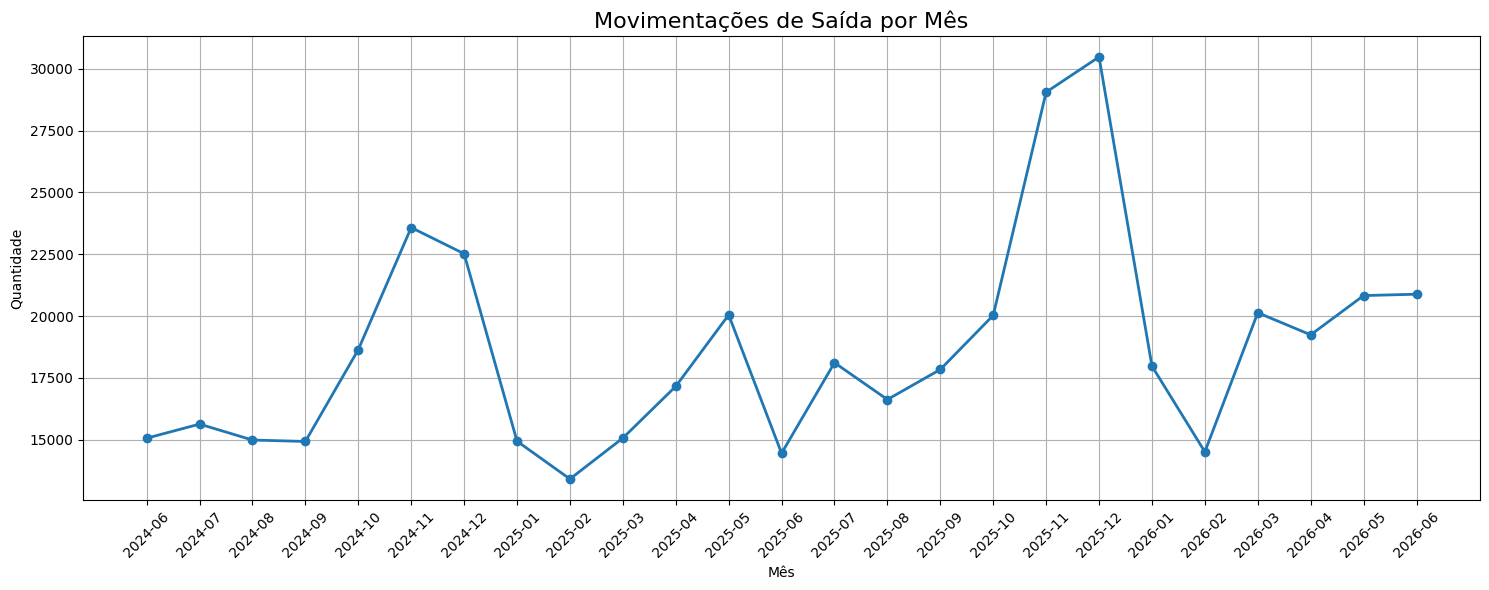

Processo concluído com sucesso.


In [ ]:
conn.close()

print('Processo concluído com sucesso.')